In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader

sys.path.append(str(Path.cwd().parent))

from src.dataset import SmSADataset, collate_fn, IDX2LABEL
from src.model import LSTMClassifier
from src.vocab import Vocab

ROOT = Path.cwd().parent
device = torch.device("xpu" if hasattr(torch, "xpu") and torch.xpu.is_available() else "cpu")
print(f"Using device: {device}")

Using device: xpu


In [2]:
vocab = Vocab.load(str(ROOT / "outputs" / "vocab.json"))
test_ds = SmSADataset(str(ROOT / "data" / "test_preprocess.tsv"), vocab)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

model = LSTMClassifier(vocab_size=len(vocab))
model.load_state_dict(torch.load(ROOT / "outputs" / "best_model.pt", map_location=device))
model.to(device)
model.eval()
print(f"Loaded checkpoint, vocab size: {len(vocab)}")

Loaded checkpoint, vocab size: 9074


In [3]:
all_preds, all_labels, all_texts = [], [], []

with torch.no_grad():
    for texts, lengths, labels in test_loader:
        texts = texts.to(device)
        logits = model(texts, lengths)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

all_texts = test_ds.texts  # original raw text, same order as dataset

print(classification_report(all_labels, all_preds, target_names=[IDX2LABEL[i] for i in range(3)]))

              precision    recall  f1-score   support

    negative       0.79      0.92      0.85       204
     neutral       0.79      0.60      0.68        88
    positive       0.85      0.80      0.82       208

    accuracy                           0.81       500
   macro avg       0.81      0.77      0.78       500
weighted avg       0.81      0.81      0.81       500



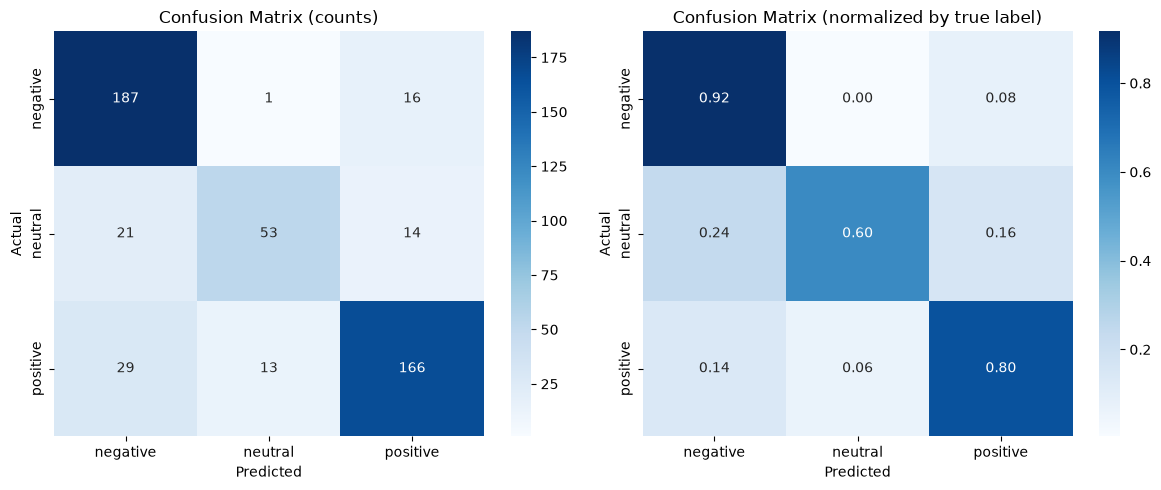

In [4]:
labels_order = [0, 1, 2]
label_names = [IDX2LABEL[i] for i in labels_order]

cm = confusion_matrix(all_labels, all_preds, labels=labels_order)
cm_norm = confusion_matrix(all_labels, all_preds, labels=labels_order, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names,
            yticklabels=label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=label_names,
            yticklabels=label_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalized by true label)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "confusion_matrix.png", dpi=150)
plt.show()

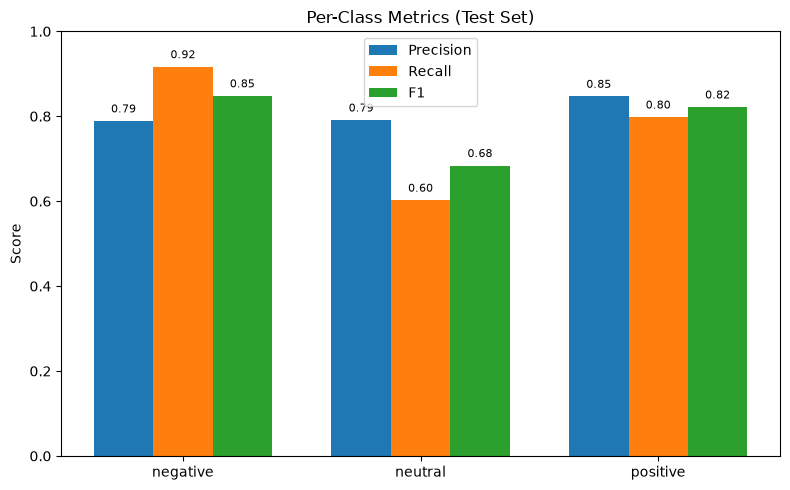

In [5]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=labels_order
)

x = np.arange(len(label_names))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1, width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(label_names)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics (Test Set)")
ax.legend()

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f"{p:.2f}", ha="center", fontsize=8)
    ax.text(i, r + 0.02, f"{r:.2f}", ha="center", fontsize=8)
    ax.text(i + width, f + 0.02, f"{f:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "per_class_metrics.png", dpi=150)
plt.show()

In [6]:
import pandas as pd

results_df = pd.DataFrame({
    "text": all_texts,
    "actual": [IDX2LABEL[l] for l in all_labels],
    "predicted": [IDX2LABEL[p] for p in all_preds],
})
misclassified = results_df[results_df["actual"] != results_df["predicted"]]

neutral_errors = misclassified[
    (misclassified["actual"] == "neutral") | (misclassified["predicted"] == "neutral")
]
print(f"Total misclassified: {len(misclassified)} / {len(results_df)}")
print(f"Neutral-related errors: {len(neutral_errors)}")
neutral_errors.head(15)

Total misclassified: 94 / 500
Neutral-related errors: 49


,text,actual,predicted
163,masyarakat papua dipastikan akan mendukung mem...,positive,neutral
176,"yang terhormat , saya suka banget sama indomie...",positive,neutral
179,xiaomi redmi note 5 atau asus zenfone max pro ...,positive,neutral
207,kalau driver go jek tidak pelayanan prima memi...,positive,neutral
213,"hai kak , terima kasih atas masukan kamu ya . ...",positive,neutral
219,harus belanja di shopee karena pelayanan dari ...,positive,neutral
250,saya suwandi sudah pesan tiket pak - cengkaren...,neutral,negative
256,"adab di media sosial itu jelas , kok . suka si...",neutral,negative
257,"kalau tidak suka gaperlu didukung mas , dukung...",neutral,negative
258,kamu bisa punya koleksi bts dengan membeli sma...,neutral,positive
